In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [78]:
iris_df = sns.load_dataset('iris')
iris_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


<Axes: xlabel='sepal_length', ylabel='petal_length'>

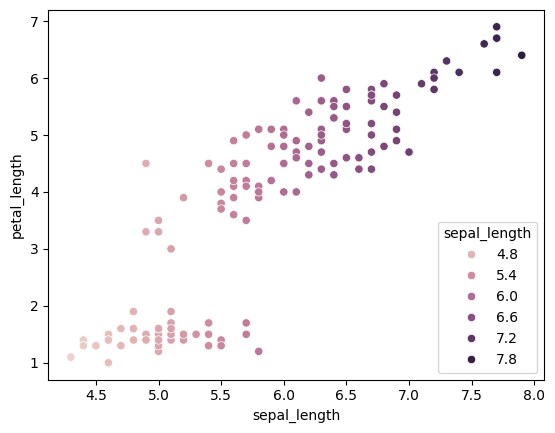

In [79]:
sns.scatterplot(data=iris_df, x='sepal_length', y='petal_length', hue='sepal_length')

<Axes: xlabel='sepal_length', ylabel='petal_width'>

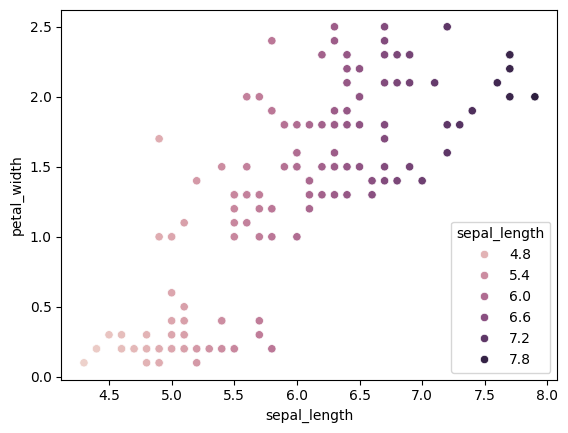

In [80]:
sns.scatterplot(data=iris_df, x='sepal_length', y='petal_width', hue='sepal_length')

<Axes: xlabel='sepal_length', ylabel='sepal_width'>

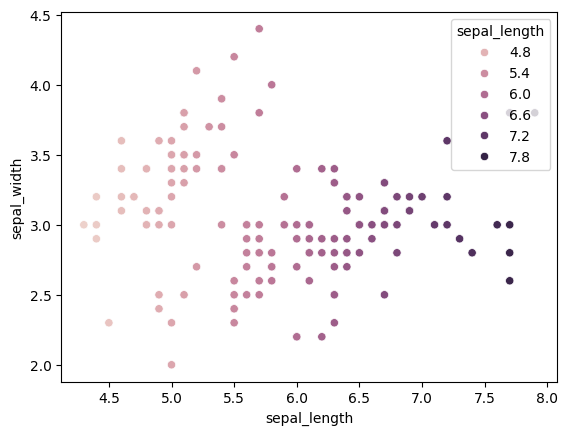

In [81]:
sns.scatterplot(data=iris_df, x='sepal_length', y='sepal_width', hue='sepal_length')

In [82]:
numeric_cols = iris_df.columns.tolist()
numeric_cols.remove('species')
numeric_cols

['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

In [83]:
X_train = iris_df[numeric_cols]
X_train.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [84]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

In [85]:
from sklearn.cluster import AgglomerativeClustering

In [86]:
# AgglomerativeClustering(n_clusters=2,
#                         *,
#                         metric='euclidean',
#                         memory=None,
#                         connectivity=None,
#                         compute_full_tree='auto',
#                         linkage='ward',
#                         distance_threshold=None,
#                         compute_distances=False,)

model = AgglomerativeClustering(n_clusters=3,
                                metric='euclidean',      # distance metric
                                linkage='ward')          # linkage method
         


In [87]:
?AgglomerativeClustering

Init signature:
AgglomerativeClustering(
    n_clusters=2,
    *,
    metric='euclidean',
    memory=None,
    connectivity=None,
    compute_full_tree='auto',
    linkage='ward',
    distance_threshold=None,
    compute_distances=False,
)
Docstring:     
Agglomerative Clustering.

Recursively merges pair of clusters of sample data; uses linkage distance.

Read more in the :ref:`User Guide <hierarchical_clustering>`.

Parameters
----------
n_clusters : int or None, default=2
    The number of clusters to find. It must be ``None`` if
    ``distance_threshold`` is not ``None``.

metric : str or callable, default="euclidean"
    Metric used to compute the linkage. Can be "euclidean", "l1", "l2",
    "manhattan", "cosine", or "precomputed". If linkage is "ward", only
    "euclidean" is accepted. If "precomputed", a distance matrix is needed
    as input for the fit method. If connectivity is None, linkage is
    "single" and affinity is not "precomputed" any valid pairwise distance
    met

In [88]:
clusters = model.fit_predict(X_scaled)

In [89]:
iris_df['Cluster'] = clusters
print(iris_df.head())

   sepal_length  sepal_width  petal_length  petal_width species  Cluster
0           5.1          3.5           1.4          0.2  setosa        1
1           4.9          3.0           1.4          0.2  setosa        1
2           4.7          3.2           1.3          0.2  setosa        1
3           4.6          3.1           1.5          0.2  setosa        1
4           5.0          3.6           1.4          0.2  setosa        1


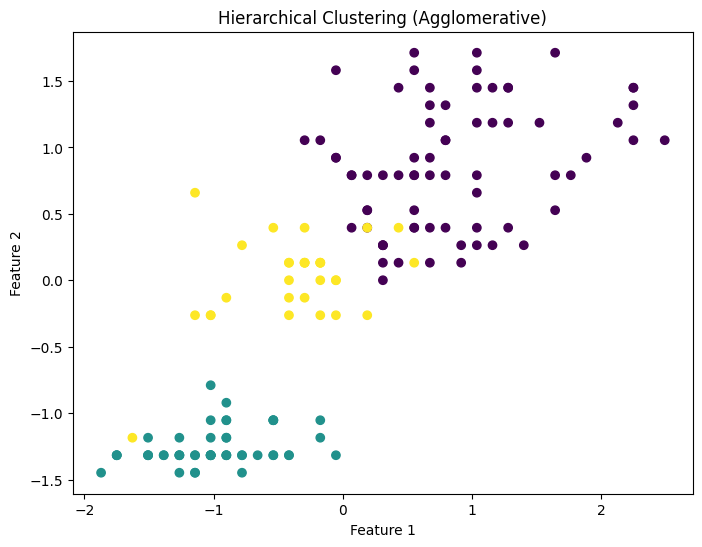

In [90]:
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 3], c=clusters)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Hierarchical Clustering (Agglomerative)")
plt.show()

In [91]:
from scipy.cluster.hierarchy import dendrogram, linkage

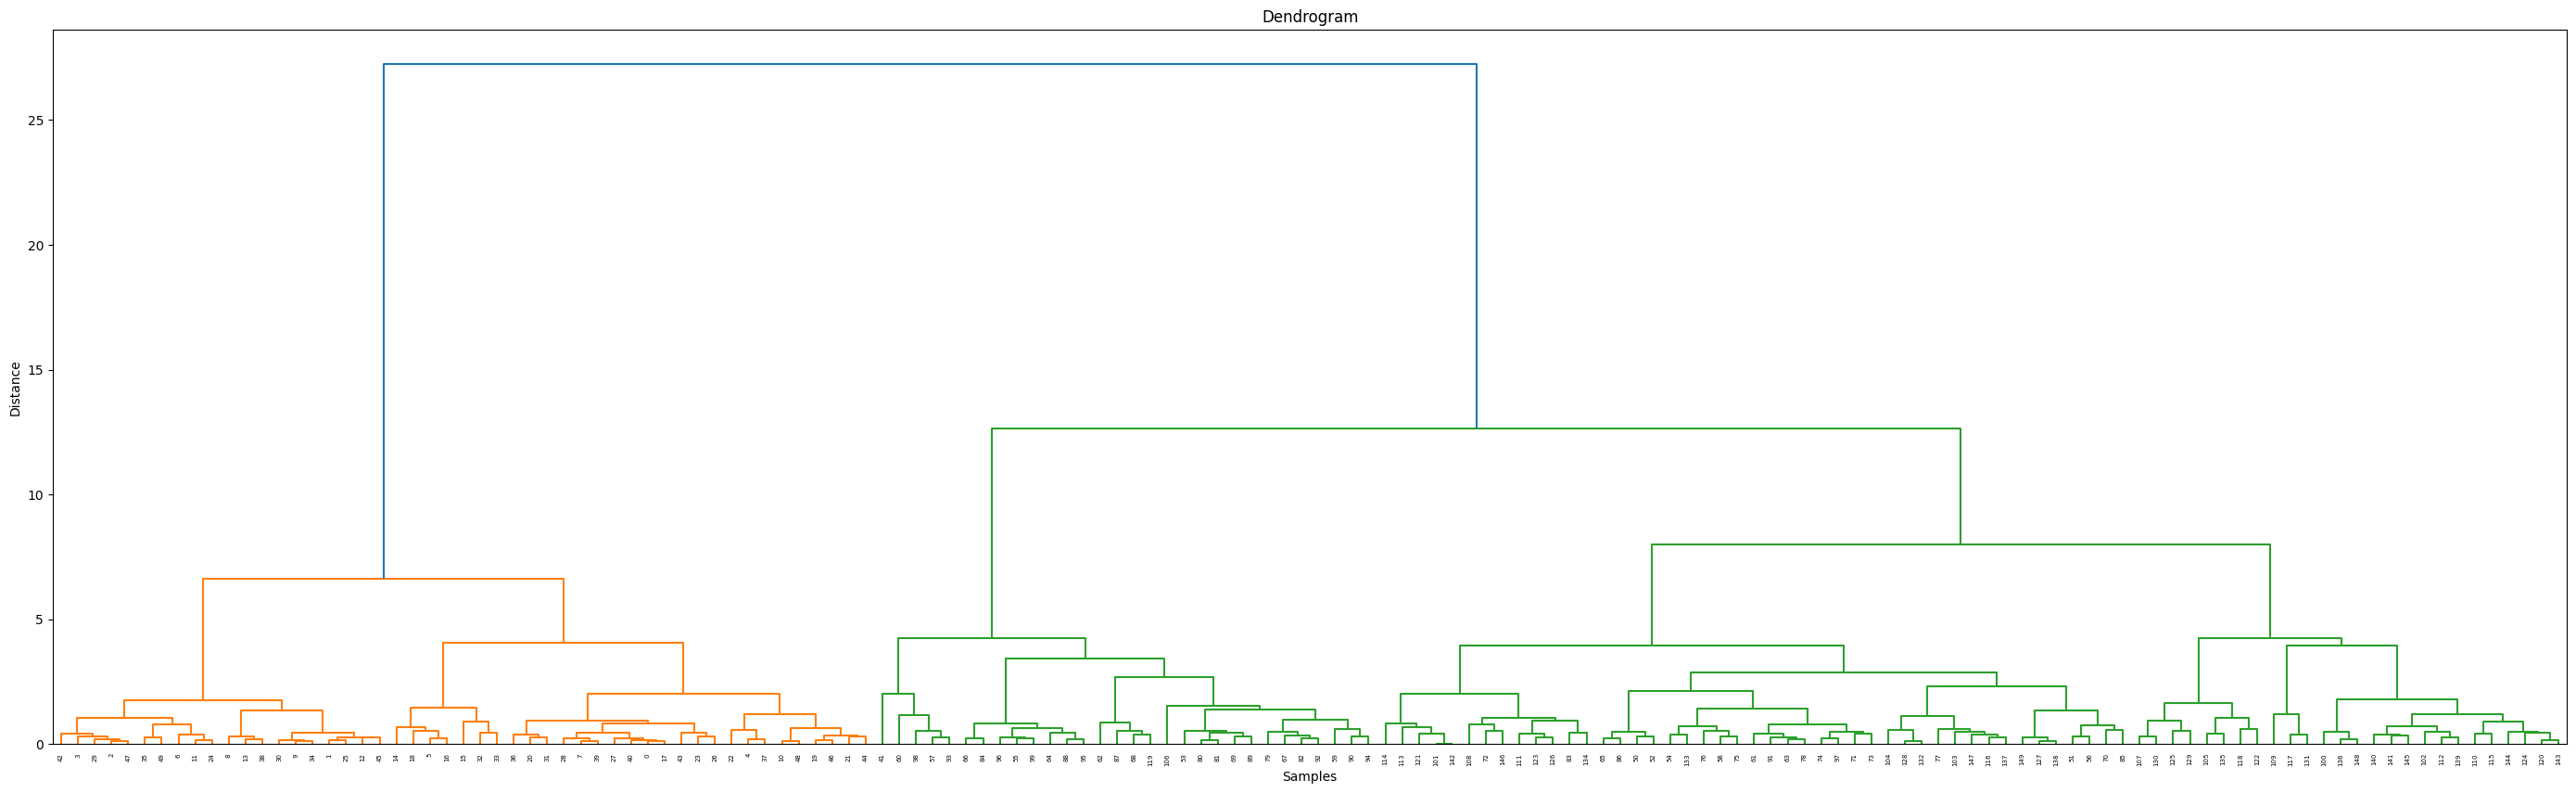

In [92]:
plt.figure(figsize=(35,10))

linked = linkage(X_scaled, method='ward')

dendrogram(linked)
plt.title("Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

In [93]:
iris_df['species'].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

Let's check with the original one

In [94]:
w1 = 0
w2 = 0
w3 = 0
for i in range(len(iris_df['species'])):
    if iris_df['species'][i] == 'setosa' and clusters.tolist()[i] != 1:
        w1+=1
    if iris_df['species'][i] == 'virginica' and clusters.tolist()[i] != 0:
        w2+=1
    if iris_df['species'][i] == 'versicolor' and clusters.tolist()[i] != 2:
        w3+=1

In [95]:
print(f'w1 = {w1}\nw2 = {w2}\nw3 = {w3}')

w1 = 1
w2 = 2
w3 = 23


In [96]:
output = pd.DataFrame({
    'speices' : iris_df['species'],
    'clusters' : clusters.tolist()
})
output

,speices,clusters
0,setosa,1
1,setosa,1
2,setosa,1
3,setosa,1
4,setosa,1
...,...,...
145,virginica,0
146,virginica,0
147,virginica,0
148,virginica,0


In [97]:
output[output['speices']=='versicolor'].value_counts()

speices     clusters
versicolor  2           27
            0           23
Name: count, dtype: int64